<img src="https://raw.githubusercontent.com/carubbi/MQ/main/notebooks/assets/imgs/unifor-logo.png" width="400">
<br>
<b>
<font size="6" face="arial" color="blue">
    Graduação em Ciência da Computação
</font>
</b>
<br>
<b>
<font size="4" face="arial">
    Disciplina: Métodos Quantitativos em Computação
</font>
</b>

**Orientador: Prof. Me. Ricardo Carubbi** <br>
*Docente da Graduação e Pós-Graduação em Ciência de Dados e Inteligência Artificial*<br>
*Laboratório de Ciência de Dados e Inteligência Artificial*<br>
*Universidade de Fortaleza*<br>

Lattes: http://lattes.cnpq.br/5738786447903616 |
GitHub: https://github.com/carubbi/

[Unifor.br](https://unifor.br/) | [Instagram](https://www.instagram.com/uniforcomunica/?hl=pt-br) | [Facebook](https://www.facebook.com/uniforoficial/) | [Twitter](https://www.facebook.com/uniforoficial/)  | [LinkedIn](https://www.linkedin.com/school/university-of-fortaleza/?originalSubdomain=pt) | [TV Unifor](https://www.unifor.br/tv-unifor) | [G1/Ensinando e Aprendendo](https://g1.globo.com/ce/ceara/especial-publicitario/unifor/ensinando-e-aprendendo/)


# **Aula 6 — Distribuições de frequências e visualização de dados**

## 1. Objetivos de aprendizagem

Ao final da aula, o aluno será capaz de:

- calcular frequências absoluta, relativa, percentual e acumulada;
- agrupar medidas em classes, indicando limites, largura e ponto médio;
- comparar Sturges e largura fixa na construção de histogramas;
- reconhecer Freedman–Diaconis e Scott como critérios computacionais que serão retomados na Aula 7;
- escolher e interpretar gráficos de categorias, distribuições, frequências acumuladas, séries temporais e pares de medidas;
- reconhecer a finalidade de Pareto, diagrama de pontos e ramo-e-folhas.

## 2. Agenda

1. Preparação dos dados — 5 min
2. Distribuições de frequências — 15 min
3. Dados agrupados em classes — 15 min
4. Critérios para definição das classes — 20 min
5. Representações gráficas — 40 min
6. Estudo e exercícios — 5 min

O carregamento e os códigos de Pareto, diagrama de pontos e ramo-e-folhas são apresentados prontos; a turma se concentra em sua leitura e interpretação. As aplicações ao Palmer Penguins serão desenvolvidas em sala. Os exercícios da seção 8 ficam para estudo após a aula.

## 3. Preparação dos dados

Vamos usar `data/processed/penguins.csv`, preparado na Aula 5. A massa está em gramas e as medidas do bico estão em milímetros. Execute as células na ordem. A leitura do CSV não preserva os tipos `category` e data definidos no notebook anterior.

In [1]:
# Importar as bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Carregar os dados preparados na Aula 5
url = 'https://raw.githubusercontent.com/carubbi/MQ/main/data/processed/penguins.csv'
df = pd.read_csv(url)
df.head()

,ID,SPECIES,ISLAND,SEX,DATE_EGG,YEAR,CULMEN_LENGTH,CULMEN_DEPTH,FLIPPER_LENGTH,BODY_MASS
0,PAL0708_N1A1,Adelie,Torgersen,male,2007-11-11,2007,39.1,18.7,181.0,3750.0
1,PAL0708_N1A2,Adelie,Torgersen,female,2007-11-11,2007,39.5,17.4,186.0,3800.0
2,PAL0708_N2A1,Adelie,Torgersen,female,2007-11-16,2007,40.3,18.0,195.0,3250.0
3,PAL0708_N2A2,Adelie,Torgersen,NaN,2007-11-16,2007,NaN,NaN,NaN,NaN
4,PAL0708_N3A1,Adelie,Torgersen,female,2007-11-16,2007,36.7,19.3,193.0,3450.0


**Tabela 1 — Primeiras observações dos dados preparados.** A coluna ID identifica cada registro; as demais colunas contêm categorias, datas e medidas. Fonte: CARUBBI, 2026, com dados de HORST; HILL; GORMAN, 2020.

In [3]:
# Selecionar a massa corporal e remover os valores ausentes
massa = df['BODY_MASS'].dropna()
massa.describe()

count     342.000000
mean     4201.754386
std       801.954536
min      2700.000000
25%      3550.000000
50%      4050.000000
75%      4750.000000
max      6300.000000
Name: BODY_MASS, dtype: float64

**Tabela 2 — Resumo da massa corporal.** Há 342 massas não ausentes, entre 2700 g e 6300 g. A exclusão de ausências não verifica a validade das medições. Fonte: CARUBBI, 2026, com dados de HORST; HILL; GORMAN, 2020.

## 4. Distribuições de frequências

### 4.1 Frequência absoluta, relativa e percentual

Uma **distribuição de frequências** mostra quantas vezes cada categoria ou valor aparece.

- **Frequência absoluta** ($f_j$): número de observações da categoria $j$.
- **Frequência relativa** ($h_j$): proporção de observações dessa categoria.
- **Percentual**: frequência relativa multiplicada por 100.

$$h_j=\frac{f_j}{n} \qquad p_j=100h_j$$

O denominador $n$ é o total de observações consideradas. As frequências absolutas somam $n$, as relativas somam 1 e os percentuais somam 100%, salvo diferenças de arredondamento (MORETTIN; BUSSAB, 2010, pp. 29–30).

### 4.2 Aplicação por espécie

Construa a distribuição de `SPECIES`. Verifique as somas e declare o denominador utilizado.

Para comparar grupos com tamanhos diferentes, use frequências relativas ou percentuais. Uma contagem maior pode resultar apenas de um grupo maior; o percentual considera o total de cada grupo (BARBETTA; REIS; BORNIA, 2010, pp. 55–56; MORETTIN; BUSSAB, 2010, p. 30).

In [4]:
# Contar as observações de cada espécie
freq = df['SPECIES'].value_counts()
freq

SPECIES
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

In [5]:
# Calcular o total de espécies preenchidas
n = df['SPECIES'].notna().sum()
n

np.int64(344)

In [6]:
# Construir a distribuição de frequências
tabela = freq.to_frame('frequencia')
tabela['relativa'] = freq / n
tabela['percentual'] = tabela['relativa'] * 100
tabela.round(3)

,frequencia,relativa,percentual
SPECIES,,,
Adelie,152,0.442,44.186
Gentoo,124,0.360,36.047
Chinstrap,68,0.198,19.767


In [7]:
# Conferir as somas das três colunas
tabela.sum()

frequencia    344.0
relativa        1.0
percentual    100.0
dtype: float64

**Tabela 3 — Distribuição por espécie.** São 152 registros Adelie, 124 Gentoo e 68 Chinstrap. O denominador é 344. Esses valores descrevem o arquivo, não a proporção de espécies na natureza. Fonte: CARUBBI, 2026, com dados de HORST; HILL; GORMAN, 2020.

### 4.3 Frequência acumulada

A **frequência acumulada** soma as frequências desde a primeira categoria ou classe até a posição considerada. Ela exige uma ordem com significado, como níveis de escolaridade ou intervalos de massa (BARBETTA; REIS; BORNIA, 2010, pp. 59–63).

Não vamos acumular frequências de espécies: ordenar seus nomes alfabeticamente não cria uma ordem estatística. A acumulação será aplicada às classes de massa na próxima seção.

No Pareto da seção 7.4, a acumulação terá outra finalidade: mostrar a participação conjunta das categorias ordenadas por frequência. Isso não cria uma ordem natural entre espécies.

## 5. Dados agrupados em classes

### 5.1 Limites, largura e ponto médio

Uma **classe** é um intervalo usado para agrupar valores quantitativos. Seus extremos são os **limites inferior e superior**. A **largura** é a diferença entre esses limites; o **ponto médio** é a média dos dois limites.

No intervalo $[3000,4000)$, o valor 3000 está incluído e o valor 4000 está excluído. A largura é 1000 g e o ponto médio é 3500 g. Classes consecutivas devem cobrir os valores sem sobreposição. O agrupamento perde o detalhe dos valores individuais (BARBETTA; REIS; BORNIA, 2010, pp. 61–63; PINHEIRO et al., 2009, pp. 29–30).

### 5.2 Aplicação com classes de 500 g

Use limites de 2700 g a 6700 g, em passos de 500 g. O último limite fica acima da maior massa, 6300 g, para incluí-la em um intervalo aberto à direita. `np.arange()` gera a sequência até antes do valor final informado.

`pd.cut()` associa cada medida a uma classe. O argumento `right=False` exclui o limite direito de cada intervalo.

In [8]:
# Criar os limites das classes
limites = np.arange(2700, 6701, 500)
limites

array([2700, 3200, 3700, 4200, 4700, 5200, 5700, 6200, 6700])

In [9]:
# Agrupar as massas não ausentes
grupo = pd.cut(massa, bins=limites, right=False)
grupo.head()

0    [3700, 4200)
1    [3700, 4200)
2    [3200, 3700)
4    [3200, 3700)
5    [3200, 3700)
Name: BODY_MASS, dtype: category
Categories (8, interval[int64, left]): [[2700, 3200) < [3200, 3700) < [3700, 4200) < [4200, 4700) < [4700, 5200) < [5200, 5700) < [5700, 6200) < [6200, 6700)]

In [10]:
# Contar as massas em cada classe
freq = grupo.value_counts(sort=False)
freq

BODY_MASS
[2700, 3200)    23
[3200, 3700)    83
[3700, 4200)    82
[4200, 4700)    55
[4700, 5200)    46
[5200, 5700)    36
[5700, 6200)    16
[6200, 6700)     1
Name: count, dtype: int64

`cumsum()` calcula a soma acumulada: cada resultado inclui a frequência da classe atual e de todas as anteriores.

In [11]:
# Construir a tabela com frequências acumuladas
tabela = freq.to_frame('frequencia')
tabela['relativa'] = freq / len(massa)
tabela['acumulada'] = freq.cumsum()
tabela

,frequencia,relativa,acumulada
BODY_MASS,,,
"[2700, 3200)",23,0.067251,23
"[3200, 3700)",83,0.242690,106
"[3700, 4200)",82,0.239766,188
"[4200, 4700)",55,0.160819,243
"[4700, 5200)",46,0.134503,289
"[5200, 5700)",36,0.105263,325
"[5700, 6200)",16,0.046784,341
"[6200, 6700)",1,0.002924,342


In [12]:
# Calcular o percentual acumulado
tabela['percentual_acum'] = tabela['acumulada'] / len(massa) * 100
tabela.round(2)

,frequencia,relativa,acumulada,percentual_acum
BODY_MASS,,,,
"[2700, 3200)",23,0.07,23,6.73
"[3200, 3700)",83,0.24,106,30.99
"[3700, 4200)",82,0.24,188,54.97
"[4200, 4700)",55,0.16,243,71.05
"[4700, 5200)",46,0.13,289,84.50
"[5200, 5700)",36,0.11,325,95.03
"[5700, 6200)",16,0.05,341,99.71
"[6200, 6700)",1,0.00,342,100.00


O ponto médio é a média dos limites da classe. Vamos acrescentá-lo à tabela usando um laço simples (BARBETTA; REIS; BORNIA, 2010, p. 62).

In [13]:
# Calcular o ponto médio de cada classe
pontos = []
for classe in tabela.index:
    ponto = (classe.left + classe.right) / 2
    pontos.append(ponto)

tabela['ponto_medio'] = pontos
tabela.round(2)

,frequencia,relativa,acumulada,percentual_acum,ponto_medio
BODY_MASS,,,,,
"[2700, 3200)",23,0.07,23,6.73,2950.0
"[3200, 3700)",83,0.24,106,30.99,3450.0
"[3700, 4200)",82,0.24,188,54.97,3950.0
"[4200, 4700)",55,0.16,243,71.05,4450.0
"[4700, 5200)",46,0.13,289,84.50,4950.0
"[5200, 5700)",36,0.11,325,95.03,5450.0
"[5700, 6200)",16,0.05,341,99.71,5950.0
"[6200, 6700)",1,0.00,342,100.00,6450.0


In [14]:
# Conferir o total de massas agrupadas
freq.sum()

np.int64(342)

**Tabela 4 — Massas em classes de 500 g.** São oito classes, fechadas à esquerda e abertas à direita. As frequências somam 342 e o percentual acumulado termina em 100%. O ponto médio representa o centro de cada intervalo. Fonte: CARUBBI, 2026, com dados de HORST; HILL; GORMAN, 2020.

**Exercício:** explique por que o total é 342 e não 344. Calcule o ponto médio da primeira classe.

**Resposta:** Duas observações não possuem massa registrada. A primeira classe é [2700, 3200), com ponto médio de 2950 g.

**Interpretação:** qual percentual das massas está abaixo de 4200 g? Consulte o percentual acumulado da classe [3700, 4200). O valor 4200 g não pertence a essa classe (BARBETTA; REIS; BORNIA, 2010, pp. 62–63).

**Resposta:** 188 das 342 massas estão abaixo de 4200 g, aproximadamente 54,97%.

## 6. Critérios para definição das classes

### 6.1 Sturges e largura fixa

A **amplitude total** é a diferença entre o maior e o menor valor. Ela não é a largura de uma classe.

Sturges sugere o número de classes:

$$k=\left\lceil1+\log_2(n)\right\rceil.$$

Aqui, $n$ é o número de observações não ausentes; $\log_2$ é o logaritmo na base 2; $\lceil\cdot\rceil$ significa arredondar para cima. O software divide o intervalo dos dados em $k$ classes.

Na **largura fixa**, escolhemos uma largura, como 500 g, e definimos limites que cubram todos os valores. A escolha das classes influencia o detalhe mostrado no histograma.

### 6.2 Cálculo com a massa corporal

Calcule o número de classes usando as massas não ausentes de `df`. Em Sturges, use a quantidade de medidas; na largura fixa, divida a amplitude total por 500 g e arredonde para cima.

In [15]:
# Calcular o número de classes por Sturges
n = len(massa)
k = int(np.ceil(1 + np.log2(n)))
k

10

In [16]:
# Calcular o número de classes de 500 g
amplitude = massa.max() - massa.min()
k = int(np.ceil(amplitude / 500))
k

8

### 6.3 Comparação computacional

Freedman–Diaconis e Scott escolhem a largura das classes usando medidas de dispersão: intervalo interquartil e desvio-padrão, respectivamente. Essas medidas serão estudadas na Aula 7. Agora, apenas compare os limites e o número de classes calculados pelo software.

`np.histogram_bin_edges()` devolve os limites das classes. O número de classes é a quantidade de limites menos um. Os resultados desta comparação são apresentados prontos.

In [17]:
# Obter os limites pelo critério de Sturges
limites_st = np.histogram_bin_edges(massa, bins='sturges')
len(limites_st) - 1

10

In [18]:
# Obter os limites pelo critério de Freedman–Diaconis
limites_fd = np.histogram_bin_edges(massa, bins='fd')
len(limites_fd) - 1

11

In [19]:
# Obter os limites pelo critério de Scott
limites_sc = np.histogram_bin_edges(massa, bins='scott')
len(limites_sc) - 1

10

In [20]:
# Conferir o número de classes de largura fixa
len(limites) - 1

8

**Exercício:** compare o número de classes dos quatro critérios. Quais critérios foram calculados pelas fórmulas da seção 6.2?

O que pode acontecer com a leitura do histograma quando usamos poucas ou muitas classes? (BARBETTA; REIS; BORNIA, 2010, p. 61).

**Resposta:** Sturges e Scott produzem 10 classes; largura fixa, 8; Freedman–Diaconis, 11. Na seção 6.2, calculamos Sturges e largura fixa com as massas do arquivo. A escolha final também exige examinar o histograma. Poucas classes podem esconder detalhes; muitas classes podem fragmentar a distribuição e dificultar a percepção de seu padrão geral.

## 7. Representações gráficas

### 7.1 Escolha do gráfico

| Gráfico | Uso nesta aula |
| --- | --- |
| Barras | Comparar frequências de categorias, como espécies. |
| Setores | Mostrar a participação das categorias no total. |
| Pareto | Ordenar categorias por frequência e mostrar sua contribuição acumulada. |
| Frequências acumuladas | Mostrar o percentual abaixo dos limites das classes. |
| Diagrama de pontos | Mostrar valores individuais e suas repetições. |
| Ramo-e-folhas | Preservar e organizar os valores de um conjunto pequeno. |
| Histograma | Mostrar a distribuição de uma medida em classes, como massa. |
| Linha | Mostrar contagens em sequência temporal. |
| Dispersão | Mostrar pares de medidas quantitativas. |

Barras representam categorias separadas. No histograma, os intervalos são contíguos; com classes de mesma largura, a altura pode representar a frequência. Indique título, nomes dos eixos e unidades (MORETTIN; BUSSAB, 2010, pp. 32–36).

Usaremos Matplotlib nos gráficos e uma saída de texto no ramo-e-folhas. `plt.figure()` inicia uma figura e `plt.show()` a exibe.

### 7.2 Barras por espécie

In [21]:
# Contar as observações por espécie
freq = df['SPECIES'].value_counts()
freq

SPECIES
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

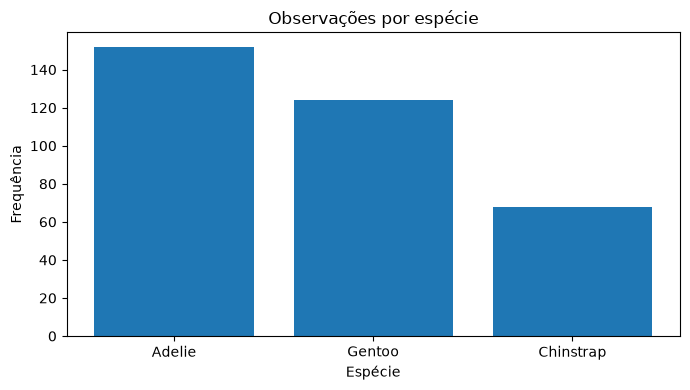

In [22]:
# Construir o gráfico de barras
plt.figure(figsize=(7, 4))
plt.bar(freq.index, freq.values)
plt.title('Observações por espécie')
plt.xlabel('Espécie')
plt.ylabel('Frequência')
plt.tight_layout()
plt.show()

**Figura 1 — Observações por espécie.** Adelie reúne 152 registros, Gentoo 124 e Chinstrap 68. O gráfico descreve a composição do arquivo. Fonte: CARUBBI, 2026, com dados de HORST; HILL; GORMAN, 2020.

### 7.3 Setores por espécie

Cada setor representa a participação de uma espécie no total. As participações somam 100%. Use esse gráfico com poucas categorias; para comparar diferenças pequenas, prefira barras (BARBETTA; REIS; BORNIA, 2010, pp. 56–57; PINHEIRO et al., 2009, p. 27).

`autopct` mostra os percentuais e `axis('equal')` mantém o círculo sem deformação.

In [23]:
# Contar as observações de cada espécie
freq = df['SPECIES'].value_counts()
freq

SPECIES
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

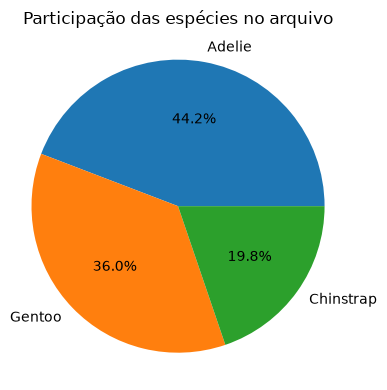

In [24]:
# Mostrar a participação de cada espécie
plt.figure(figsize=(4, 4))
plt.pie(freq.values, labels=freq.index, autopct='%1.1f%%')
plt.title('Participação das espécies no arquivo')
plt.axis('equal')
plt.tight_layout()
plt.show()

**Figura 2 — Participação por espécie.** Adelie representa 44,2%, Gentoo 36,0% e Chinstrap 19,8% dos registros. Fonte: CARUBBI, 2026, com dados de HORST; HILL; GORMAN, 2020.

### 7.4 Pareto

O diagrama de Pareto apresenta categorias em ordem decrescente de frequência. Aqui, acrescentamos uma linha com o percentual acumulado para mostrar a contribuição das categorias mais frequentes (BARBETTA; REIS; BORNIA, 2010, p. 57).

A ordem vem da frequência observada, não de uma ordem natural das espécies. O gráfico descreve a composição do arquivo; não estabelece prioridade de conservação nem implica uma regra de 80/20.

O código é apresentado pronto. `twinx()` acrescenta o eixo de percentuais à direita; o eixo da esquerda mostra as contagens.

In [25]:
# Ordenar as frequências e calcular o percentual acumulado
freq = df['SPECIES'].value_counts()
acum = freq.cumsum() / freq.sum() * 100
acum

SPECIES
Adelie        44.186047
Gentoo        80.232558
Chinstrap    100.000000
Name: count, dtype: float64

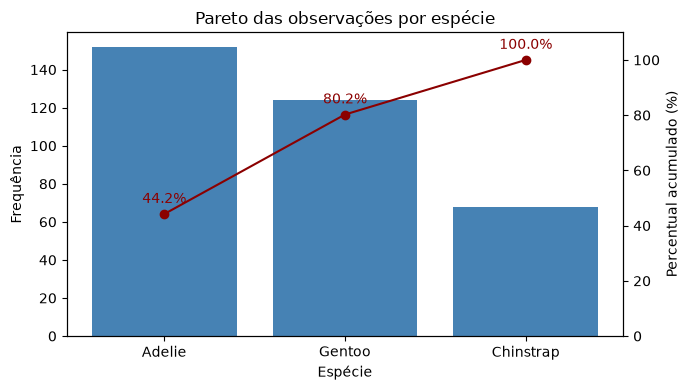

In [26]:
# Representar contagens em ordem decrescente
fig, eixo = plt.subplots(figsize=(7, 4))
eixo.bar(freq.index, freq.values, color='steelblue')
eixo.set_xlabel('Espécie')
eixo.set_ylabel('Frequência')

# Acrescentar o percentual acumulado no eixo direito
eixo_pct = eixo.twinx()
eixo_pct.plot(freq.index, acum.values, color='darkred', marker='o')
eixo_pct.set_ylabel('Percentual acumulado (%)')
eixo_pct.set_ylim(0, 110)

# Mostrar o percentual em cada ponto
for especie, percentual in acum.items():
    eixo_pct.annotate(f'{percentual:.1f}%', (especie, percentual),
                      xytext=(0, 8), textcoords='offset points',
                      ha='center', color='darkred')

eixo.set_title('Pareto das observações por espécie')
fig.tight_layout()
plt.show()

**Figura 3 — Pareto por espécie.** As barras mostram 152, 124 e 68 registros. Adelie e Gentoo, juntas, reúnem aproximadamente 80,2% do arquivo. Fonte: CARUBBI, 2026, com dados de HORST; HILL; GORMAN, 2020.

### 7.5 Histogramas da massa

Compare os mesmos dados usando Sturges e classes de 500 g. Nos histogramas do Matplotlib, o último intervalo inclui o limite direito; os anteriores são abertos à direita.

A área de cada retângulo é proporcional à frequência da classe. Como usamos classes de mesma largura em cada histograma, podemos comparar diretamente as alturas. Com larguras diferentes, a altura deve considerar a frequência dividida pela largura, chamada densidade de frequência (BARBETTA; REIS; BORNIA, 2010, p. 64; MORETTIN; BUSSAB, 2010, pp. 35–36).

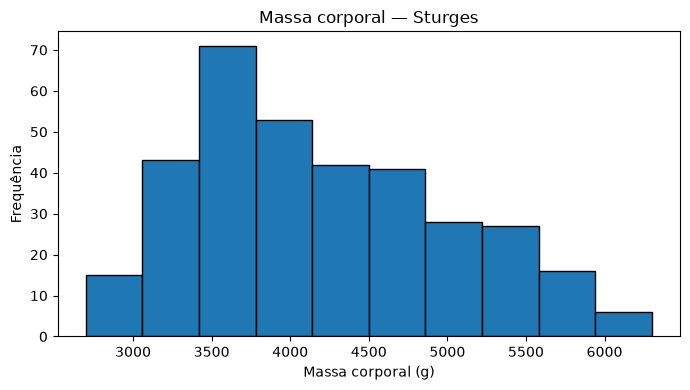

In [27]:
# Construir o histograma por Sturges
plt.figure(figsize=(7, 4))
plt.hist(massa, bins=limites_st, edgecolor='black')
plt.title('Massa corporal — Sturges')
plt.xlabel('Massa corporal (g)')
plt.ylabel('Frequência')
plt.tight_layout()
plt.show()

**Figura 4 — Massa corporal por Sturges.** As 342 massas são distribuídas em dez classes. A classe [3420, 3780) tem a maior frequência, com 71 observações. Fonte: CARUBBI, 2026, com dados de HORST; HILL; GORMAN, 2020.

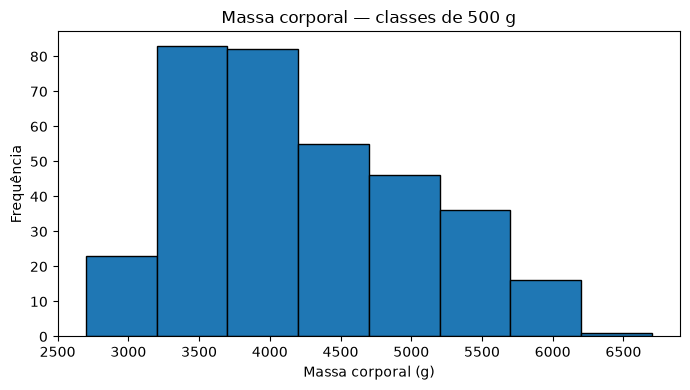

In [28]:
# Construir o histograma com classes de 500 g
plt.figure(figsize=(7, 4))
plt.hist(massa, bins=limites, edgecolor='black')
plt.title('Massa corporal — classes de 500 g')
plt.xlabel('Massa corporal (g)')
plt.ylabel('Frequência')
plt.tight_layout()
plt.show()

**Figura 5 — Massa corporal em classes de 500 g.** A classe [3200, 3700) contém 83 observações e [3700, 4200), 82. Os dados são os mesmos; os limites alteram a distribuição das contagens pelas classes. Fonte: CARUBBI, 2026, com dados de HORST; HILL; GORMAN, 2020.

### 7.6 Gráfico de frequências acumuladas

O gráfico acumulado, também chamado **ogiva** quando construído com classes, mostra o percentual abaixo de cada limite superior. Ele começa em 0% no limite inferior da primeira classe e termina em 100% no último limite superior (BARBETTA; REIS; BORNIA, 2010, pp. 62–63).

Vamos usar o percentual acumulado da tabela de massas. Como as classes são abertas à direita, o valor em 4200 g representa as massas menores que 4200 g. Entre os limites, os segmentos são uma aproximação: não recuperam os valores individuais.

In [29]:
# Acrescentar o percentual inicial de zero à sequência da tabela
percentuais = [0]
for percentual in tabela['percentual_acum']:
    percentuais.append(percentual)
percentuais

[0,
 6.725146198830409,
 30.994152046783626,
 54.97076023391813,
 71.05263157894737,
 84.50292397660819,
 95.02923976608187,
 99.70760233918129,
 100.0]

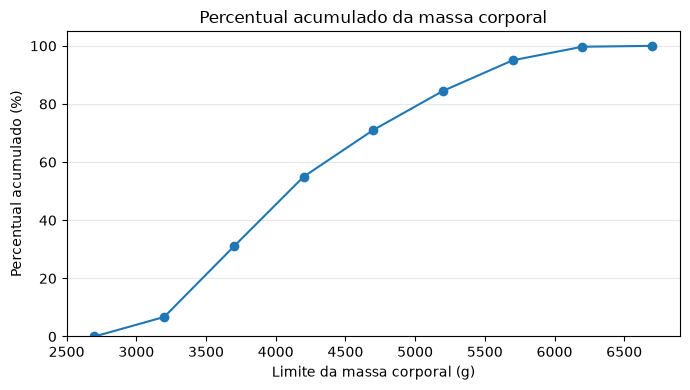

In [30]:
# Representar o percentual acumulado nos limites das classes
plt.figure(figsize=(7, 4))
plt.plot(limites, percentuais, marker='o')
plt.title('Percentual acumulado da massa corporal')
plt.xlabel('Limite da massa corporal (g)')
plt.ylabel('Percentual acumulado (%)')
plt.ylim(0, 105)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Figura 6 — Percentual acumulado da massa corporal.** Abaixo de 4200 g estão 188 das 342 massas não ausentes, ou 54,97%. A curva não diminui, pois cada classe acrescenta observações ao total acumulado. Fonte: CARUBBI, 2026, com dados de HORST; HILL; GORMAN, 2020.

### 7.7 Diagrama de pontos

Cada ponto representa uma medida. Valores repetidos são empilhados na mesma posição horizontal, preservando a informação que o histograma reúne em classes (MORETTIN; BUSSAB, 2010, pp. 33–34; BARBETTA; REIS; BORNIA, 2010, pp. 64–65).

Usaremos as 342 massas não ausentes. A altura de cada pilha indica quantas vezes aquela massa foi registrada. O código é apresentado pronto.

In [31]:
# Contar as repetições de cada massa
freq_pontos = massa.value_counts().sort_index()
freq_pontos.head()

BODY_MASS
2700.0    1
2850.0    2
2900.0    4
2925.0    1
2975.0    1
Name: count, dtype: int64

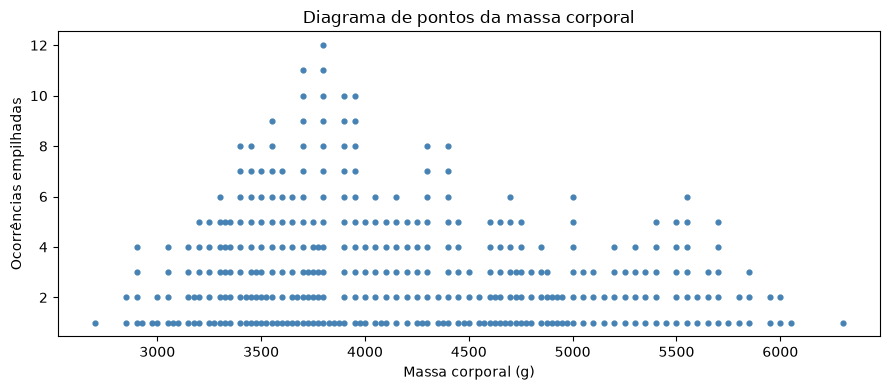

In [32]:
# Empilhar um ponto para cada ocorrência de uma massa
plt.figure(figsize=(9, 4))
for valor, quantidade in freq_pontos.items():
    x = [valor] * quantidade
    y = range(1, quantidade + 1)
    plt.scatter(x, y, s=12, color='steelblue')
plt.title('Diagrama de pontos da massa corporal')
plt.xlabel('Massa corporal (g)')
plt.ylabel('Ocorrências empilhadas')
plt.tight_layout()
plt.show()

**Figura 7 — Diagrama de pontos da massa corporal.** Cada ponto corresponde a uma das 342 medidas. As pilhas mostram repetições dos valores registrados, sem agrupamento em intervalos. Fonte: CARUBBI, 2026, com dados de HORST; HILL; GORMAN, 2020.

### 7.8 Ramo-e-folhas

O ramo-e-folhas separa cada valor em duas partes e preserva os valores individuais. Para comprimentos inteiros em milímetros, usaremos as dezenas como **ramo** e a unidade como **folha** (MORETTIN; BUSSAB, 2010, pp. 37–39; PINHEIRO et al., 2009, pp. 31–32).

Para facilitar a leitura, mostre apenas as primeiras 20 medidas não ausentes de `FLIPPER_LENGTH`. Esse recorte ilustra a construção; não é uma amostra aleatória nem resume o arquivo inteiro. O código é apresentado pronto.

`// 10` extrai as dezenas e `% 10` extrai a unidade. Por exemplo, a chave `18 | 1 = 181 mm` explica como reconstruir o valor.

In [33]:
# Selecionar e ordenar as primeiras 20 medidas não ausentes
nadadeira = df['FLIPPER_LENGTH'].dropna().head(20)
nadadeira = nadadeira.sort_values()
nadadeira

20    174.0
11    180.0
6     181.0
0     181.0
12    182.0
18    184.0
15    185.0
1     186.0
10    186.0
5     190.0
9     190.0
13    191.0
8     193.0
4     193.0
19    194.0
2     195.0
7     195.0
16    195.0
17    197.0
14    198.0
Name: FLIPPER_LENGTH, dtype: float64

In [34]:
# Construir o ramo-e-folhas com as medidas selecionadas
ramos = {}
for medida in nadadeira:
    valor = int(medida)
    ramo = valor // 10
    folha = valor % 10
    if ramo not in ramos:
        ramos[ramo] = []
    ramos[ramo].append(folha)

# Exibir os ramos e as folhas em ordem
print('Ramo | Folhas')
for ramo, folhas in ramos.items():
    print(ramo, '|', *folhas)
print('Chave: 18 | 1 = 181 mm')

Ramo | Folhas
17 | 4
18 | 0 1 1 2 4 5 6 6
19 | 0 0 1 3 3 4 5 5 5 7 8
Chave: 18 | 1 = 181 mm


**Diagrama 1 — Ramo-e-folhas do comprimento da nadadeira.** As 20 folhas correspondem às primeiras 20 medidas não ausentes, em ordem crescente. Cada medida pode ser reconstruída usando a chave. Fonte: CARUBBI, 2026, com dados de HORST; HILL; GORMAN, 2020.

### 7.9 Contagens por data

Converta `DATE_EGG` para data, selecione o período de coleta de 2009 e conte os registros de cada dia. O calendário completo permite manter lacunas nos dias sem registros. Ausência de registro não significa ausência de pinguins.

A linha conecta contagens em ordem temporal. Não use essa ligação para categorias sem ordem.

In [35]:
# Converter a coluna de datas
datas = pd.to_datetime(df['DATE_EGG'], format='%Y-%m-%d')
# Selecionar o período de coleta de 2009
datas = datas[datas.dt.year == 2009]
datas.head()

100   2009-11-09
101   2009-11-09
102   2009-11-15
103   2009-11-15
104   2009-11-15
Name: DATE_EGG, dtype: datetime64[us]

In [36]:
# Contar os registros por data
contagens = datas.value_counts().sort_index()
contagens.head()

DATE_EGG
2009-11-09    4
2009-11-10    4
2009-11-12    2
2009-11-13    4
2009-11-14    2
Name: count, dtype: int64

`pd.date_range()` cria uma sequência diária. `reindex()` alinha as contagens a esse calendário e deixa valores ausentes nos dias não registrados. Esse trecho é apresentado pronto.

In [37]:
# Criar o calendário e preservar os dias sem registro
calendario = pd.date_range(datas.min(), datas.max(), freq='D')
contagens = contagens.reindex(calendario)

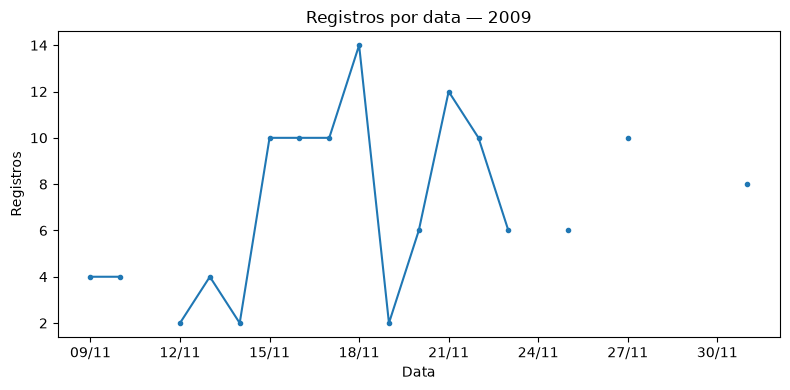

In [38]:
# Representar os registros ao longo do tempo
plt.figure(figsize=(8, 4))
plt.plot(contagens.index, contagens.values, marker='o', markersize=3)
plt.title('Registros por data — 2009')
plt.xlabel('Data')
plt.ylabel('Registros')
plt.xticks(contagens.index[::3], contagens.index[::3].strftime('%d/%m'), rotation=0)
plt.tight_layout()
plt.show()

**Figura 8 — Registros por data em 2009.** São 120 registros em 17 datas, de 9 de novembro a 1º de dezembro. O maior total diário é 14, em 18 de novembro. Os intervalos sem linha indicam dias sem registros no arquivo. Fonte: CARUBBI, 2026, com dados de HORST; HILL; GORMAN, 2020.

### 7.10 Dispersão das medidas do bico

Selecione comprimento e profundidade na mesma linha e retire apenas os pares com alguma medida ausente. Excluir ausências de cada coluna separadamente pode desfazer os pares.

Cada ponto representa duas medidas da mesma observação. Os pontos não devem ser ligados.

In [39]:
# Selecionar pares com as duas medidas preenchidas
pares = df[['CULMEN_LENGTH', 'CULMEN_DEPTH']].dropna()
pares.head()

,CULMEN_LENGTH,CULMEN_DEPTH
0,39.1,18.7
1,39.5,17.4
2,40.3,18.0
4,36.7,19.3
5,39.3,20.6


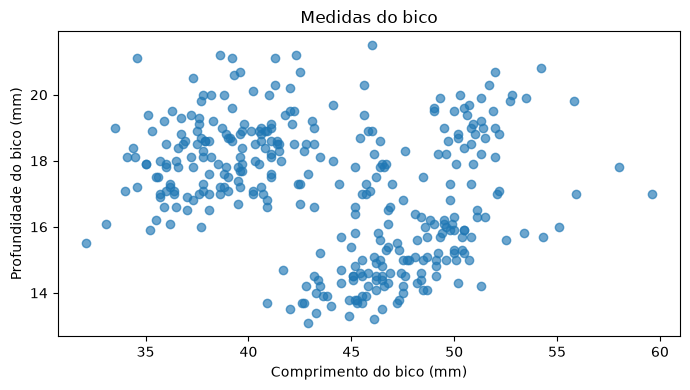

In [40]:
# Representar os pares de medidas do bico
plt.figure(figsize=(7, 4))
plt.scatter(pares['CULMEN_LENGTH'], pares['CULMEN_DEPTH'], alpha=0.65)
plt.title('Medidas do bico')
plt.xlabel('Comprimento do bico (mm)')
plt.ylabel('Profundidade do bico (mm)')
plt.tight_layout()
plt.show()

**Figura 9 — Medidas do bico.** Os 342 pares completos formam agrupamentos visuais. O gráfico permite levantar perguntas sobre as espécies; não demonstra causalidade. Fonte: CARUBBI, 2026, com dados de HORST; HILL; GORMAN, 2020.

### 7.11 Interpretação

Para cada gráfico, escreva uma pergunta que ele permite responder. Compare os dois histogramas e explique o que muda quando os limites das classes mudam.

Compare barras e setores. Explique como a acumulação no Pareto difere da acumulação por massa e qual informação pode ser recuperada no ramo-e-folhas.

**Resposta:** Barras comparam categorias; histogramas mostram a distribuição de uma medida; linhas organizam contagens no tempo; dispersões mostram pares de medidas. Nos dois histogramas, as massas e seus extremos permanecem iguais, mas as contagens por classe e o detalhe visual mudam. Setores mostram participações no total. O Pareto acumula contribuições de categorias ordenadas por frequência; a ogiva acumula observações segundo valores crescentes de massa. Pontos e ramo-e-folhas preservam os valores individuais apresentados.

## 8. Estudo e exercícios

### 8.1 Materiais didáticos

1. BARBETTA; REIS; BORNIA (2010), seções 3.2 e 3.3, páginas PDF 54–68: frequências e representações de variáveis qualitativas e quantitativas.
2. PINHEIRO et al. (2009), seção 1.4, páginas PDF 25–32: tabelas de frequências, setores, histogramas e ramo-e-folhas.
3. MORETTIN; BUSSAB (2010), seções 2.2 a 2.4, páginas PDF 29–39: frequências, gráficos, diagrama de pontos e ramo-e-folhas.

As páginas indicadas correspondem à posição no arquivo PDF.

### 8.2 Exercícios indicados

No [Banco de questões e provas 2026.2](../../apostila/banco_questoes_provas_2026_2.pdf):

- questão 37, página 17: interpretação de frequências em um histograma;
- questão 44, página 20: construção de histograma e descrição da distribuição.

Indique o total de observações, os limites das classes e as unidades. Justifique as respostas pelas frequências.

### 8.3 Atividade prática

Use a coluna `FLIPPER_LENGTH` do arquivo preparado na Aula 5.

1. Conte as medidas não ausentes.
2. Construa uma distribuição de frequências com classes de 10 mm, cobrindo do menor ao maior valor.
3. Calcule frequências relativas e acumuladas. Confira o total.
4. Faça dois histogramas: um com essas classes e outro com Sturges.
5. Compare os gráficos em duas frases, identificando uma semelhança e uma diferença.

Use uma tarefa por célula, nomes curtos e comentários objetivos.

## 9. Referências

1. BARBETTA, Pedro Alberto; REIS, Marcelo Menezes; BORNIA, Antonio Cezar. *Estatística para cursos de engenharia e informática*. 3. ed. São Paulo: Atlas, 2010.
2. PINHEIRO, João Ismael D. et al. *Estatística básica: a arte de trabalhar com dados*. Rio de Janeiro: Elsevier, 2009.
3. MORETTIN, Pedro A.; BUSSAB, Wilton O. *Estatística básica*. 6. ed. São Paulo: Saraiva, 2010.
4. HORST, Allison Marie; HILL, Alison Presmanes; GORMAN, Kristen B. *palmerpenguins: Palmer Archipelago (Antarctica) penguin data*. Zenodo, 2020. DOI: [10.5281/zenodo.3960218](https://doi.org/10.5281/zenodo.3960218).
5. FREEDMAN, David; DIACONIS, Persi. On the histogram as a density estimator: $L_2$ theory. *Zeitschrift für Wahrscheinlichkeitstheorie und verwandte Gebiete*, v. 57, p. 453–476, 1981.
6. SCOTT, David W. *Multivariate density estimation: theory, practice, and visualization*. 2. ed. Hoboken: Wiley, 2015.
7. NUMPY DEVELOPERS. *NumPy documentation*. Disponível em: [numpy.org/doc](https://numpy.org/doc/).
8. PANDAS DEVELOPMENT TEAM. *pandas documentation*. Disponível em: [pandas.pydata.org/docs](https://pandas.pydata.org/docs/).
9. CARUBBI, Ricardo. *Distribuições de frequências e visualização de dados*. Material de aula. Universidade de Fortaleza, 2026.